# EMiF – Class 3: Empirical applications with `Data_HEC_3.xlsx`

This notebook is built to **connect the formulas/models from _EMiF-Class3_ to real data**.

We use three tabs:

- **US Equities** – market betas and their historical stability
- **Swiss Equities** – the same exercise on Swiss stocks
- **Taylor Rule** – OLS Taylor rule, residual autocorrelation, and **MLE estimation with MA(q) errors**  
  → then a diagnostic showing why **OLS betas can be biased/inconsistent** if we overlook the MA component.

> Pedagogical goal: keep the code readable and “reproducible”.  
> You can reuse the functions below in your own projects.

---

## Plan

1. **US equities**: returns, excess returns, CAPM betas, rolling betas (stability)
2. **Swiss equities**: same logic (market = SMI)
3. **Taylor rule**: OLS, residual ACF, MLE with MA(q) noise, and bias diagnostics (OLS vs MLE + simulation)


In [1]:
import os
os.makedirs("TP3_outputs", exist_ok=True)

# --- Imports (standard scientific stack) ---
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from scipy.optimize import minimize
from statsmodels.tsa.stattools import acf
from statsmodels.stats.diagnostic import acorr_ljungbox

# Display options (nice in class)
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)
np.set_printoptions(precision=4, suppress=True)

# Path to the Excel file (keep it in the same folder as this notebook)
DATA_PATH = "Data_HEC_3.xlsx"

# Where we export figures and tables for your Beamer slides
FIG_DIR = "TP3_outputs"
TAB_DIR = "TP3_outputs"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

def save_figure(name):
    """Save current Matplotlib figure as PDF (vector) + PNG (raster)."""
    pdf_path = os.path.join(FIG_DIR, f"{name}.pdf")
    png_path = os.path.join(FIG_DIR, f"{name}.png")
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {pdf_path} and {png_path}")

def export_table(df, name, floatfmt="%.3f"):
    """Export a pandas table to CSV + LaTeX (for Beamer)."""
    csv_path = os.path.join(TAB_DIR, f"{name}.csv")
    tex_path = os.path.join(TAB_DIR, f"{name}.tex")
    df.to_csv(csv_path)
    df.to_latex(tex_path, float_format=floatfmt)
    print(f"Saved: {csv_path} and {tex_path}")


In [2]:
# --- Load the three tabs ---
xl = pd.ExcelFile(DATA_PATH)
sheets = xl.sheet_names
sheets


['US Equities', 'Swiss Equities', 'Taylor Rule']

In [3]:
dfs = {name: pd.read_excel(DATA_PATH, sheet_name=name) for name in sheets}

for name, df in dfs.items():
    print(f"\n{name} – shape = {df.shape}")
    display(df.head(3))



US Equities – shape = (521, 10)


,Unnamed: 0,S&P500,Growth,Value,Quality,Risk Free Rate,Nvidia,Alphabet,Meta,Apple
0,2016-03-11,2022.19,1135.97,878.85999,1445.4580,0.36,0.8055,37.2435,109.41,25.5650
1,2016-03-18,2049.58,1149.53,892.21002,1469.6730,0.36,0.8453,37.7705,111.45,26.4800
2,2016-03-25,2035.94,1147.74,881.63000,1459.6899,0.37,0.8620,37.7420,113.05,26.4175



Swiss Equities – shape = (322, 6)


,Unnamed: 0,SMI,Risk Free Rate,Nestle,Logitech,Roche
0,2020-01-03,10699.82,-0.75,106.32,46.00,316.10
1,2020-01-10,10639.49,-0.75,102.94,46.50,320.40
2,2020-01-17,10841.82,-0.75,106.58,44.72,327.95



Taylor Rule – shape = (660, 4)


,Unnamed: 0,Fed Fund Rates,US Inflation,Output Gap
0,1971-03-31,5.5,4.712,-0.7435
1,1971-04-30,5.5,4.156,-0.7920
2,1971-05-31,5.5,4.404,-0.8890


## Common pre-processing

In both equity tabs, the first column is a **date**, the other columns are **levels** (indices/prices).  
So we will work with (log) returns:

\[
r_t = \log\left(\frac{P_t}{P_{t-1}}\right)
\]

Each tab also contains a **risk-free rate**. In the spreadsheet it looks like an **annualized % rate**.  
For weekly equity data, we approximate the weekly risk-free return by:

\[
r^f_t \approx \frac{\text{RiskFreeRate}_t}{100 \times 52}
\]

This is intentionally simple for teaching purposes.


## A “from scratch” OLS (with constant)

You asked to **implement OLS ourselves** (with an intercept).  
We use the closed-form formula:

$$
\hat\beta = (X'X)^{-1}X'y
$$

and compute standard errors with the usual homoskedastic covariance estimator:

$$
\widehat{\text{Var}}(\hat\beta) = \hat\sigma^2 (X'X)^{-1},\qquad
\hat\sigma^2 = \frac{1}{T-k}\sum_{t=1}^T \hat u_t^2
$$

Later in the Taylor rule section, we will discuss why serial correlation / MA noise breaks the standard inference.


In [4]:
# Part 0 – A simple “from scratch” OLS (with a constant)

def ols_with_const(y, X, x_names=None):
    """
    OLS with intercept (constant) – implemented “by hand”.
    This version is robust to singular (non-invertible) X'X by using a pseudo-inverse.

    Inputs
    ------
    y : array-like of shape (T,)
    X : array-like of shape (T,) or (T,k)  (WITHOUT the constant)
    x_names : list of regressor names (length k) (optional)

    Returns
    -------
    res : dict with keys:
        beta, se, t, yhat, resid, r2, sigma2, vcov, columns
    """
    y = np.asarray(y).reshape(-1, 1)
    X = np.asarray(X)

    if X.ndim == 1:
        X = X.reshape(-1, 1)

    # Drop missing / non-finite observations (important in real datasets)
    ok = np.isfinite(y).flatten()
    for j in range(X.shape[1]):
        ok = ok & np.isfinite(X[:, j])
    y = y[ok, :]
    X = X[ok, :]

    T = y.shape[0]
    Xc = np.column_stack([np.ones(T), X])  # add constant
    k = Xc.shape[1]

    # beta = (X'X)^+ X'y   where ^+ is pseudo-inverse
    XtX = Xc.T @ Xc
    Xty = Xc.T @ y
    XtX_inv = np.linalg.pinv(XtX)
    beta = XtX_inv @ Xty   # (k,1)

    yhat = Xc @ beta
    resid = y - yhat

    # R^2
    sse = float(np.squeeze(resid.T @ resid))
    sst = float(np.squeeze((y - y.mean()).T @ (y - y.mean())))
    r2 = 1.0 - sse/sst if sst > 0 else np.nan

    # sigma^2
    dof = T - k
    sigma2 = sse / dof

    # Var(beta) = sigma2 (X'X)^+
    vcov = sigma2 * XtX_inv
    se = np.sqrt(np.diag(vcov)).reshape(-1, 1)
    tstat = beta / se

    if x_names is None:
        columns = ["const"] + [f"x{j}" for j in range(1, k)]
    else:
        columns = ["const"] + list(x_names)

    return {
        "beta": beta.flatten(),
        "se": se.flatten(),
        "t": tstat.flatten(),
        "yhat": yhat.flatten(),
        "resid": resid.flatten(),
        "r2": r2,
        "sigma2": float(sigma2),
        "vcov": vcov,
        "columns": columns,
        "nobs": T
    }

def summarize_ols(res):
    """Pretty table for coefficients."""
    return pd.DataFrame(
        {"beta": res["beta"], "se": res["se"], "t": res["t"]},
        index=res["columns"]
    )

# Quick sanity check (optional)
np.random.seed(0)
T = 200
x = np.random.randn(T)
y = 1.0 + 2.0*x + np.random.randn(T)
res_test = ols_with_const(y, x, ["x"])
display(summarize_ols(res_test))


,beta,se,t
const,0.867034,0.067003,12.940147
x,2.069825,0.065441,31.629059


# Part 1 – US equities: betas and stability

We treat **S&P500** as the market proxy.  
For each series \(i\), we estimate a CAPM-style regression on **excess returns**:

\[
r^e_{i,t} = \alpha_i + \beta_i \, r^e_{m,t} + u_{i,t}
\]

Then we look at **rolling-window betas** to illustrate that betas are not “constants of nature”.


In [5]:
us = dfs["US Equities"].copy()
us = us.rename(columns={"Unnamed: 0": "Date"}).set_index("Date").sort_index()

us.columns


Index(['S&P500', 'Growth', 'Value', 'Quality', 'Risk Free Rate', 'Nvidia', 'Alphabet', 'Meta', 'Apple'], dtype='str')

In [6]:
# Compute weekly log returns from levels
price_cols = [c for c in us.columns if c != "Risk Free Rate"]
rf_col = "Risk Free Rate"

us_ret = np.log(us[price_cols]).diff().dropna()

# Approximate weekly risk-free return (annualized % -> weekly decimal)
rf_weekly = (us[rf_col] / 100.0 / 52.0).loc[us_ret.index]

# Excess returns
us_excess = us_ret.sub(rf_weekly, axis=0)

display(us_excess.head())


,S&P500,Growth,Value,Quality,Nvidia,Alphabet,Meta,Apple
Date,,,,,,,,
2016-03-18,0.013385,0.011797,0.015007,0.016544,0.048159,0.013982,0.018405,0.035096
2016-03-25,-0.006748,-0.001630,-0.012000,-0.006887,0.019493,-0.000826,0.014183,-0.002434
2016-04-01,0.017862,0.023930,0.011578,0.020743,0.047282,0.019385,0.026206,0.039997
2016-04-08,-0.012290,-0.011178,-0.013453,-0.004035,-0.013770,-0.013408,-0.047983,-0.012233
2016-04-15,0.015979,0.011553,0.020589,0.012538,0.040378,0.026602,-0.009060,0.010821


In [7]:
# CAPM betas vs the market (S&P500) – we EXCLUDE the factor indices from the “stocks” list

mkt = "S&P500"
factor_cols_us = ["S&P500", "Growth", "Value", "Quality"]
stock_cols_us = [c for c in us_excess.columns if (c not in factor_cols_us)]

# 1) CAPM: stock excess return on market excess return
rows = []
for a in stock_cols_us:
    y = us_excess[a].values
    X = us_excess[mkt].values
    res = ols_with_const(y, X, [mkt])
    rows.append([a, res["beta"][0], res["beta"][1], res["r2"]])

beta_table_us_capm = pd.DataFrame(rows, columns=["asset", "alpha", "beta_mkt", "R2"]).set_index("asset")
beta_table_us_capm = beta_table_us_capm.sort_values("beta_mkt", ascending=False)

display(beta_table_us_capm.round(3))

# Export table for your slides
export_table(beta_table_us_capm.round(4), "us_capm_betas")


,alpha,beta_mkt,R2
asset,,,
Nvidia,0.007,1.688,0.409
Meta,0.001,1.135,0.293
Apple,0.002,1.112,0.467
Alphabet,0.002,1.047,0.430


Saved: tables\us_capm_betas.csv and tables\us_capm_betas.tex


,alpha,beta_S&P500,beta_Growth,beta_Value,beta_Quality,R2
asset,,,,,,
Nvidia,0.005,4.256,-0.151,-2.851,0.252,0.543
Alphabet,0.002,-2.840,3.136,1.241,-0.656,0.549
Meta,0.001,-3.741,3.776,1.442,-0.530,0.393
Apple,0.001,4.093,-1.194,-2.138,0.295,0.530


Saved: tables\us_multifactor_betas.csv and tables\us_multifactor_betas.tex
Saved: figures\us_factor_betas_Nvidia.pdf and figures\us_factor_betas_Nvidia.png


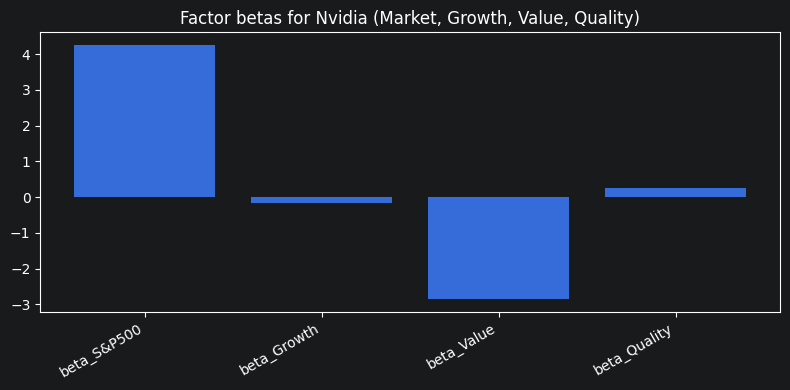

In [8]:
# 2) Multi-factor regression: stock excess return on (Market, Growth, Value, Quality)

X_factors = us_excess[factor_cols_us].values  # (T,4)

rows = []
for a in stock_cols_us:
    y = us_excess[a].values
    res = ols_with_const(y, X_factors, factor_cols_us)
    # coefficients: [const, beta_mkt, beta_growth, beta_value, beta_quality]
    rows.append([a, res["beta"][0], *res["beta"][1:], res["r2"]])

cols = ["asset", "alpha"] + [f"beta_{c}" for c in factor_cols_us] + ["R2"]
beta_table_us_ff = pd.DataFrame(rows, columns=cols).set_index("asset")

display(beta_table_us_ff.round(3))

# Export table for your slides
export_table(beta_table_us_ff.round(4), "us_multifactor_betas")

# Simple plot: factor betas for one illustrative stock (kept fixed for slide reproducibility)
example_stock = "Nvidia"
if example_stock not in beta_table_us_ff.index:
    example_stock = beta_table_us_ff.index[0]

ex = beta_table_us_ff.loc[example_stock, [f"beta_{c}" for c in factor_cols_us]]

plt.figure(figsize=(8,4))
plt.bar(ex.index, ex.values)
plt.title(f"Factor betas for {example_stock} (Market, Growth, Value, Quality)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
save_figure(f"us_factor_betas_{example_stock}")
plt.show()


## Rolling betas (stability)

We estimate betas on a rolling window (default: **52 weeks ≈ 1 year**).  
This mimics a common risk-management practice: “beta monitoring”.


In [9]:
def rolling_beta(y, x, window=52):
    """
    Rolling CAPM beta using our own OLS.
    Returns a time series of betas aligned at the window end.
    """
    betas = []
    idx = []
    for t in range(window, len(y) + 1):
        y_w = y.iloc[t-window:t].values
        x_w = x.iloc[t-window:t].values
        res = ols_with_const(y_w, x_w, [x.name])
        betas.append(res["beta"][1])   # slope on x
        idx.append(y.index[t-1])
    return pd.Series(betas, index=idx, name=f"beta({y.name}|{x.name})")

WINDOW = 52

roll_betas = pd.DataFrame({
    a: rolling_beta(us_excess[a], us_excess[mkt], window=WINDOW)
    for a in stock_cols_us
})

roll_betas.tail()


,Nvidia,Alphabet,Meta,Apple
2026-01-30,1.846196,1.122402,1.506374,1.357455
2026-02-06,1.864454,1.110820,1.523529,1.342809
2026-02-13,1.842367,1.147547,1.521158,1.356707
2026-02-20,1.845158,1.137832,1.495461,1.382454
2026-02-27,1.835475,1.118680,1.494033,1.380991


Saved: figures\us_rolling_market_betas.pdf and figures\us_rolling_market_betas.png


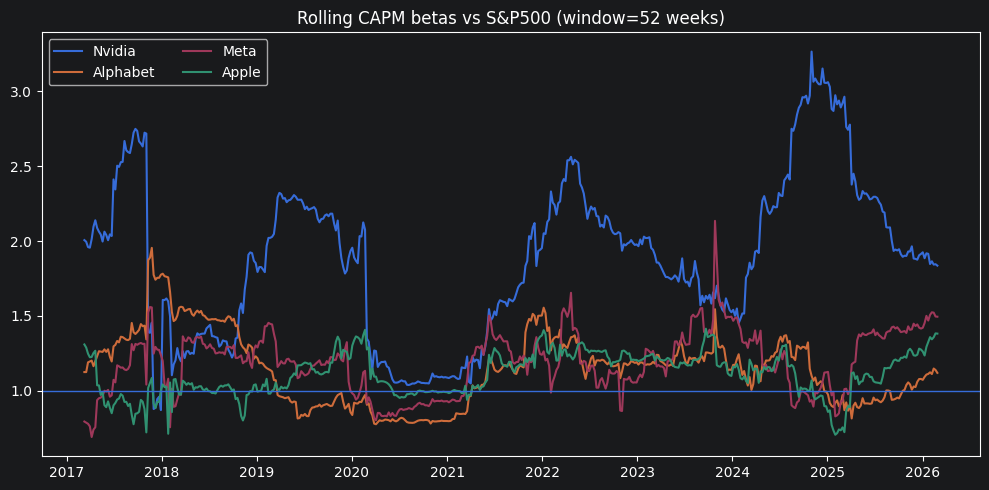

In [10]:
# Plot rolling betas (market beta stability)
plt.figure(figsize=(10, 5))
for a in stock_cols_us:
    plt.plot(roll_betas.index, roll_betas[a], label=a)
plt.axhline(1.0, linewidth=1)
plt.title(f"Rolling CAPM betas vs {mkt} (window={WINDOW} weeks)")
plt.legend(ncol=2)
plt.tight_layout()
save_figure("us_rolling_market_betas")
plt.show()


### Discussion prompts (for class)

1. Which names have the highest and lowest betas? Does it match intuition?
2. Identify a period where betas shift materially. What macro/market regime could explain it?
3. Try **WINDOW = 104** (two years). Does the beta “look” more stable? What is the trade-off?


# Part 2 – Swiss equities: betas and stability (market = SMI)

Same workflow:

- transform prices into weekly (log) returns
- compute excess returns using the CHF risk-free rate
- estimate CAPM betas for **Nestlé, Logitech, Roche** vs **SMI**
- rolling betas to discuss stability/regimes


In [11]:
ch = dfs["Swiss Equities"].copy()
ch = ch.rename(columns={"Unnamed: 0": "Date"}).set_index("Date").sort_index()

price_cols_ch = [c for c in ch.columns if c != "Risk Free Rate"]
rf_col_ch = "Risk Free Rate"

ch_ret = np.log(ch[price_cols_ch]).diff().dropna()
rf_weekly_ch = (ch[rf_col_ch] / 100.0 / 52.0).loc[ch_ret.index]
ch_excess = ch_ret.sub(rf_weekly_ch, axis=0)

display(ch_excess.head())


,SMI,Nestle,Logitech,Roche
Date,,,,
2020-01-10,-0.005510,-0.032163,0.010955,0.013656
2020-01-17,0.018983,0.034894,-0.038887,0.023435
2020-01-24,0.000875,0.021678,0.054753,-0.013518
2020-01-31,-0.020517,-0.023268,-0.085348,0.002614
2020-02-07,0.034698,0.024475,0.022494,0.047421


In [12]:
mkt_ch = "SMI"
assets_ch = [c for c in ch_excess.columns if c != mkt_ch]

rows = []
for a in assets_ch:
    res = ols_with_const(ch_excess[a].values, ch_excess[mkt_ch].values, [mkt_ch])
    rows.append([a, res["beta"][0], res["beta"][1], res["r2"]])

beta_table_ch = pd.DataFrame(rows, columns=["asset", "alpha", "beta_mkt", "R2"]).set_index("asset")
beta_table_ch = beta_table_ch.sort_values("beta_mkt", ascending=False)

display(beta_table_ch.round(3))

# Export table for your slides
export_table(beta_table_ch.round(4), "ch_capm_betas")


,alpha,beta_mkt,R2
asset,,,
Logitech,0.000,1.068,0.211
Roche,-0.000,0.960,0.455
Nestle,-0.001,0.726,0.403


Saved: tables\ch_capm_betas.csv and tables\ch_capm_betas.tex


Saved: figures\ch_rolling_market_betas.pdf and figures\ch_rolling_market_betas.png


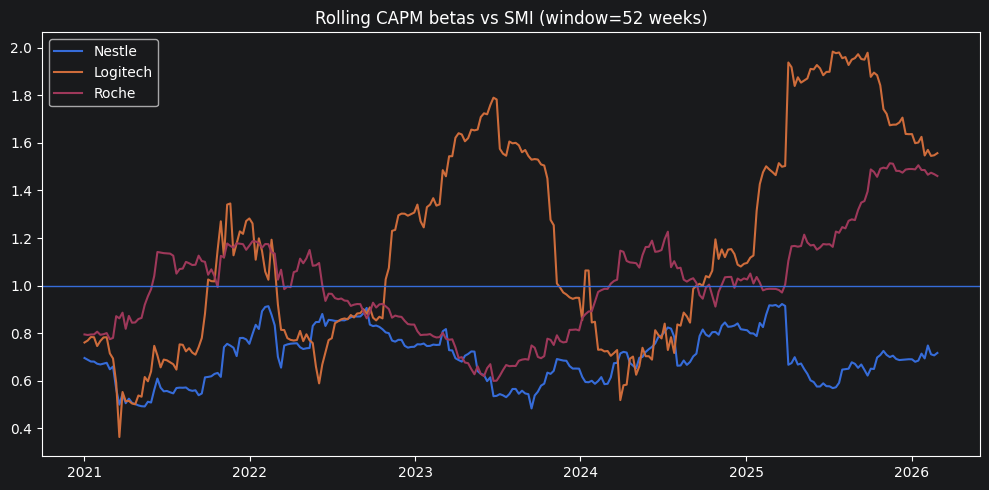

In [13]:
WINDOW_CH = 52
roll_betas_ch = pd.DataFrame({
    a: rolling_beta(ch_excess[a], ch_excess[mkt_ch], window=WINDOW_CH)
    for a in assets_ch
})

plt.figure(figsize=(10, 5))
for a in assets_ch:
    plt.plot(roll_betas_ch.index, roll_betas_ch[a], label=a)
plt.axhline(1.0, linewidth=1)
plt.title(f"Rolling CAPM betas vs {mkt_ch} (window={WINDOW_CH} weeks)")
plt.legend()
plt.tight_layout()
save_figure("ch_rolling_market_betas")
plt.show()


### Extension ideas (optional)

- Estimate a **two-factor** model: market + “global equity” (e.g., S&P500 in CHF).  
  → question: does it reduce the residual variance?
- Test whether beta is stable before/after 2022 (simple split sample).


# Part 3 – Taylor rule: OLS, residual autocorrelation, MA(q) likelihood, bias diagnostics

We start from a baseline Taylor rule:

\begin{align}
i_t = \alpha + \phi_\pi \pi_t + \phi_y y_t + u_t
\end{align}

Then we look at an “inertial” version (interest-rate smoothing):

\begin{align}
i_t = \alpha + \phi_\pi \pi_t + \phi_y y_t + \rho i_{t-1} + u_t
\end{align}

Key point: if the disturbance \(u_t\) is **serially correlated** and, in particular, has an **MA(q)** structure,
then:

1. OLS standard errors are wrong (inference issue)
2. in the inertial model, OLS betas can become **biased/inconsistent** because \(i_{t-1}\) becomes correlated with \(u_t\)

We will show this in data and then in a small simulation.


In [14]:
tr = dfs["Taylor Rule"].copy()
tr = tr.rename(columns={"Unnamed: 0": "Date"}).set_index("Date").sort_index()

# Build lagged policy rate (for inertia)
tr["Fed Funds Lag1"] = tr["Fed Fund Rates"].shift(1)

tr = tr.dropna()
tr.head()


,Fed Fund Rates,US Inflation,Output Gap,Fed Funds Lag1
Date,,,,
1971-04-30,5.50,4.156,-0.792000,5.5
1971-05-31,5.50,4.404,-0.889000,5.5
1971-06-30,5.50,4.639,-0.901333,5.5
1971-07-31,5.50,4.359,-0.913667,5.5
1971-08-31,5.75,4.615,-0.926000,5.5


In [15]:
# --- OLS: baseline and inertial Taylor rule ---
y = tr["Fed Fund Rates"].values

X_base = tr[["US Inflation", "Output Gap"]].values
res_base = ols_with_const(y, X_base, ["Inflation", "OutputGap"])

X_iner = tr[["US Inflation", "Output Gap", "Fed Funds Lag1"]].values
res_iner = ols_with_const(y, X_iner, ["Inflation", "OutputGap", "i(t-1)"])

print("Baseline Taylor rule")
display(summarize_ols(res_base))
print(f"R2 = {res_base['r2']:.3f}\n")

print("Inertial Taylor rule (with i(t-1))")
display(summarize_ols(res_iner))
print(f"R2 = {res_iner['r2']:.3f}")


# Export coefficient tables for slides
export_table(summarize_ols(res_base).round(6), "taylor_ols_baseline_coefs", floatfmt="%.6f")
export_table(summarize_ols(res_iner).round(6), "taylor_ols_inertial_coefs", floatfmt="%.6f")


Baseline Taylor rule


,beta,se,t
const,1.503135,0.180386,8.332877
Inflation,0.891429,0.035850,24.865352
OutputGap,0.220120,0.051226,4.297037


R2 = 0.500

Inertial Taylor rule (with i(t-1))


,beta,se,t
const,0.065120,0.046505,1.400279
Inflation,0.040084,0.012177,3.291824
OutputGap,0.044672,0.012693,3.519308
i(t-1),0.959369,0.009484,101.154874


R2 = 0.970
Saved: tables\taylor_ols_baseline_coefs.csv and tables\taylor_ols_baseline_coefs.tex
Saved: tables\taylor_ols_inertial_coefs.csv and tables\taylor_ols_inertial_coefs.tex


## Residual autocorrelation diagnostics

A first quick check is the **ACF** of OLS residuals and the Ljung–Box test.  
If we see significant autocorrelation, it suggests that we should enrich the error structure.

In many macro applications, a short **MA(1)** or **MA(2)** is already enough to capture residual dynamics.


Saved: figures\taylor_acf_resid_baseline_ols.pdf and figures\taylor_acf_resid_baseline_ols.png


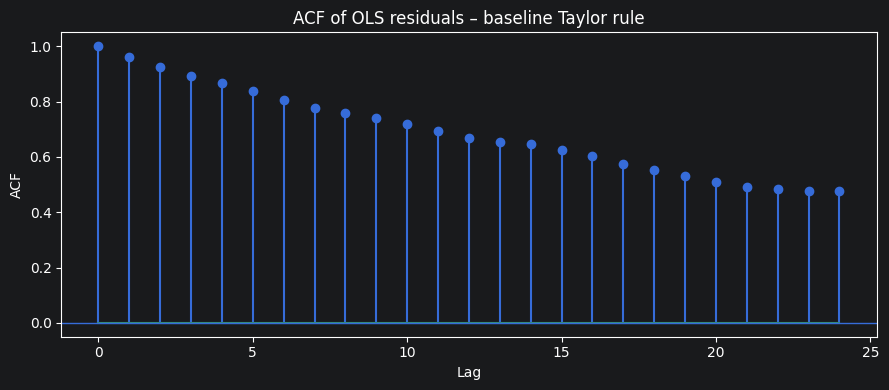

Saved: figures\taylor_acf_resid_inertial_ols.pdf and figures\taylor_acf_resid_inertial_ols.png


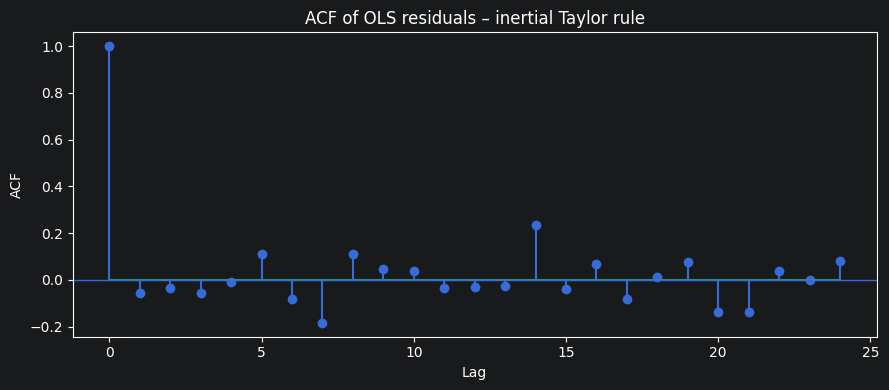

Ljung–Box p-values – baseline


,lb_stat,lb_pvalue
6,3106.673800,0.0
12,5228.272953,0.0
18,6740.758612,0.0
24,7747.110365,0.0


Ljung–Box p-values – inertial


,lb_stat,lb_pvalue
6,17.621813,7.250182e-03
12,52.460138,5.137678e-07
18,99.271957,3.010603e-13
24,133.806042,3.159948e-17


In [16]:
def plot_acf(series, nlags=24, title="", fig_name=None):
    a = acf(np.asarray(series).flatten(), nlags=nlags, fft=True)
    plt.figure(figsize=(9, 4))
    plt.stem(range(len(a)), a)
    plt.axhline(0.0, linewidth=1)
    plt.title(title)
    plt.xlabel("Lag")
    plt.ylabel("ACF")
    plt.tight_layout()
    if fig_name is not None:
        save_figure(fig_name)
    plt.show()

# ACF of residuals (exported for slides)
plot_acf(res_base["resid"], nlags=24, title="ACF of OLS residuals – baseline Taylor rule", fig_name="taylor_acf_resid_baseline_ols")
plot_acf(res_iner["resid"], nlags=24, title="ACF of OLS residuals – inertial Taylor rule", fig_name="taylor_acf_resid_inertial_ols")

# Ljung-Box test (several lags)
lb_base = acorr_ljungbox(res_base["resid"], lags=[6, 12, 18, 24], return_df=True)
lb_iner = acorr_ljungbox(res_iner["resid"], lags=[6, 12, 18, 24], return_df=True)

print("Ljung–Box p-values – baseline")
display(lb_base[["lb_stat","lb_pvalue"]])

print("Ljung–Box p-values – inertial")
display(lb_iner[["lb_stat","lb_pvalue"]])


## Estimation with MA(q) disturbances by maximum likelihood

Assume:

\[
u_t = \varepsilon_t + \theta_1 \varepsilon_{t-1} + \dots + \theta_q \varepsilon_{t-q},\qquad
\varepsilon_t \sim \mathcal{N}(0,\sigma^2)
\]

Given \(\beta\) and \(\theta\), we compute \(u_t = y_t - X_t \beta\).  
Then we **invert** the MA recursion (conditional likelihood) to obtain \(\varepsilon_t\):

\[
\varepsilon_t = u_t - \theta_1 \varepsilon_{t-1} - \dots - \theta_q \varepsilon_{t-q}
\]

We “concentrate out” \(\sigma^2\) using \(\hat\sigma^2 = \frac{1}{T}\sum \varepsilon_t^2\).
So maximizing the likelihood becomes equivalent to **minimizing** \(\log(\hat\sigma^2)\).

Below is a simple implementation meant for teaching.


In [17]:
def ma_innovations(u, theta):
    """
    MA(q) inversion (conditional likelihood):
        u_t = eps_t + theta1 eps_{t-1} + ... + thetaq eps_{t-q}
    =>  eps_t = u_t - theta1 eps_{t-1} - ... - thetaq eps_{t-q}
    with eps_{t<=0} = 0.
    """
    u = np.asarray(u).flatten()
    theta = np.asarray(theta).flatten()
    q = len(theta)
    T = len(u)

    eps = np.zeros(T)
    for t in range(T):
        acc = 0.0
        for j in range(1, q+1):
            if t-j >= 0:
                acc += theta[j-1] * eps[t-j]
        eps[t] = u[t] - acc
    return eps

def negloglik_concentrated(params, y, X, q):
    """
    params = [beta0..betak, theta1..thetaq]
    X is WITHOUT constant (we add it inside).
    We concentrate out sigma^2 and minimize log(sigma^2).
    """
    y = np.asarray(y).flatten()
    X = np.asarray(X)
    if X.ndim == 1:
        X = X.reshape(-1,1)
    T = len(y)

    Xc = np.column_stack([np.ones(T), X])
    k = Xc.shape[1]

    beta = params[:k]
    theta = params[k:k+q]

    u = y - Xc @ beta
    eps = ma_innovations(u, theta)

    sigma2 = np.mean(eps**2)
    if (sigma2 <= 1e-12) or (not np.isfinite(sigma2)):
        return 1e12

    return float(0.5 * T * np.log(sigma2))

def estimate_taylor_ma(y, X, q=1, start_theta=None):
    """
    Numerical MLE for:
        y = Xc beta + u
        u = MA(q)

    Returns a dict with beta, theta, sigma2 and optimizer info.
    """
    y = np.asarray(y).flatten()
    X = np.asarray(X)
    if X.ndim == 1:
        X = X.reshape(-1,1)

    # Starting point: OLS betas + theta = 0
    res_ols = ols_with_const(y, X)
    T = len(y)
    Xc = np.column_stack([np.ones(T), X])
    k = Xc.shape[1]

    if start_theta is None:
        start_theta = np.zeros(q)

    x0 = np.concatenate([res_ols["beta"], start_theta])

    obj = lambda p: negloglik_concentrated(p, y=y, X=X, q=q)
    out = minimize(obj, x0, method="BFGS")

    p_hat = out.x
    beta_hat = p_hat[:k]
    theta_hat = p_hat[k:k+q]

    u_hat = y - Xc @ beta_hat
    eps_hat = ma_innovations(u_hat, theta_hat)
    sigma2_hat = np.mean(eps_hat**2)

    return {
        "success": bool(out.success),
        "message": str(out.message),
        "beta": beta_hat,
        "theta": theta_hat,
        "sigma2": float(sigma2_hat),
        "fun": float(out.fun),
        "nit": int(out.nit)
    }

mle_base_ma1 = estimate_taylor_ma(y, X_base, q=1)
mle_iner_ma1 = estimate_taylor_ma(y, X_iner, q=1)

mle_base_ma1, mle_iner_ma1


({'success': True,
  'message': 'Optimization terminated successfully.',
  'beta': array([1.5785, 0.8707, 0.2096]),
  'theta': array([0.8099]),
  'sigma2': 2.594664215499082,
  'fun': 314.1641182460211,
  'nit': 15},
 {'success': False,
  'message': 'Desired error not necessarily achieved due to precision loss.',
  'beta': array([0.059 , 0.0368, 0.044 , 0.9632]),
  'theta': array([-0.0672]),
  'sigma2': 0.4264388522083027,
  'fun': -280.82833369842115,
  'nit': 13})

## Compare OLS vs MLE(MA(1))

We compare coefficients side-by-side.  
Focus especially on the inertial model: if \(u_t\) has an MA component, then \(i_{t-1}\) may become correlated with \(u_t\),
and OLS can drift away from the likelihood-based estimate.


In [18]:
def coef_table(ols_res, mle_res, names):
    idx = ["const"] + names
    out = pd.DataFrame(
        {"OLS": ols_res["beta"], "MLE_MA1": mle_res["beta"]},
        index=idx
    )
    out["diff (MLE-OLS)"] = out["MLE_MA1"] - out["OLS"]
    return out

print("Baseline model:")
display(coef_table(res_base, mle_base_ma1, ["Inflation","OutputGap"]))

print("Inertial model:")
display(coef_table(res_iner, mle_iner_ma1, ["Inflation","OutputGap","i(t-1)"]))


export_table(coef_table(res_base, mle_base_ma1, ["Inflation","OutputGap"]).round(6), "taylor_coef_compare_baseline", floatfmt="%.6f")
export_table(coef_table(res_iner, mle_iner_ma1, ["Inflation","OutputGap","i(t-1)"]).round(6), "taylor_coef_compare_inertial", floatfmt="%.6f")


Baseline model:


,OLS,MLE_MA1,diff (MLE-OLS)
const,1.503135,1.578523,0.075389
Inflation,0.891429,0.870743,-0.020686
OutputGap,0.220120,0.209590,-0.010530


Inertial model:


,OLS,MLE_MA1,diff (MLE-OLS)
const,0.065120,0.058994,-0.006126
Inflation,0.040084,0.036767,-0.003317
OutputGap,0.044672,0.043981,-0.000691
i(t-1),0.959369,0.963214,0.003845


Saved: tables\taylor_coef_compare_baseline.csv and tables\taylor_coef_compare_baseline.tex
Saved: tables\taylor_coef_compare_inertial.csv and tables\taylor_coef_compare_inertial.tex


## What students should take away

1. **Betas move** over time (rolling estimates).  
   → stability is an empirical question, not a theoretical assumption.

2. Taylor rule regressions often have **serial correlation** in residuals.  
   → ignoring it breaks inference; with inertia, it can also break consistency.

3. A simple MA(q) likelihood can be coded with:
   - a recursion to compute innovations
   - a numeric optimizer
